In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

In [2]:
from tavily import TavilyClient
from typing import Literal

tavily_client = TavilyClient(api_key=os.getenv("TAVILY_API_KEY"))

def web_search(query: str, max_results: int = 5,
               topics: Literal["general","sport","finance","news"]="general",
               include_raw_content:bool=False):
    """Run a web search""" 
    return tavily_client.search(query,max_results=max_results,include_raw_content=include_raw_content,topics=topics)

In [10]:
from langchain_openai import ChatOpenAI

model = ChatOpenAI(
    model="gpt-5",
    temperature=0,
    max_tokens=256,
)

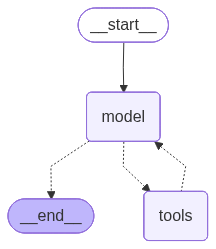

In [11]:
#SIMPLE AGENT
from langchain.agents import create_agent

simple_agent = create_agent(
    model=model,
    tools=[web_search]
)
simple_agent

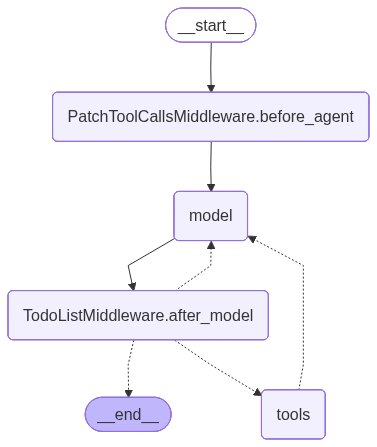

In [12]:
#DEEP AGENT
from deepagents import create_deep_agent

deepagent=create_deep_agent(
    model=model,
    tools=[web_search],
    system_prompt = "You are a reasearch assistant that helps users find information on the web. You can use the web search tool to find relevant information and answer user queries." 
)
deepagent

In [ ]:
msgs = [{"role":"user","content":"What is the latest news on the economy?"}]
result = deepagent.invoke({"messages": msgs})

In [ ]:
result['messages'][-1].content